# 1 - Importing necessary libraries

In [1]:
import xarray as xr
import matplotlib.pylab as plt
import numpy as np
# from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
# import scipy.spatial.qhull as qhull
# import matplotlib.tri as mtri
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
from matplotlib import cm
%matplotlib inline

from aqua import Reader, catalogue
# catalogue(configdir='/home/a/a270223/AQUA/config')
catalogue(configdir='/work/ab0995/a270223/AQUA/config')
# path = '/home/a/a270223/AQUA/config/levante/catalog.yaml'
path = '/work/ab0995/a270223/AQUA/config/levante/catalog.yaml'

# import warnings
# warnings.filterwarnings('ignore')

Importing dask for this use case gets rid of the HDF5-DIAG Errors that otherwise occur.

In [ ]:
import dask
from distributed import Client
from dask_cuda import LocalCUDACluster

with dask.config.set(jit_unspill=True):
    client = Client(n_workers=16, threads_per_worker=1, memory_limit='8GB')

client.cluster

# 2 - Getting data from the intake catalogue via the Reader function

In [3]:
reader = Reader(model="FESOM", exp="tco2559-ng5", source="original_2d", regrid="r005")
fesom_cat = reader.retrieve(fix=False)

This is the original ungridded fesom dataset.

In [4]:
fesom_cat

<xarray.Dataset>
Dimensions:   (time: 8328, nod2: 7402886)
Coordinates:
  * time      (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Data variables: (12/19)
    MLD1      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    MLD2      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    a_ice     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_y  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmoce_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    ...        ...
    ssh       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sss       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sst       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    uice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vve_5     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
Attributes: (12/17)
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       469e74b1
    FESOM_MeshPath:                      /ec/res4/scratch/natr/RAPS/20/inputs...
    FESOM_mesh_representative_checksum:  
    FESOM_ClimateDataPath:               /ec/res4/scratch/natr/RAPS/20/inputs...
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      1
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    -1
    history:                             2023-04-17 15:19:42 retrieved by AQU...

# 3 - Selecting Sea Surface Height data from the entire Fesom dataset

In [5]:
fesom_ssh = fesom_cat['ssh']
fesom_ssh

<xarray.DataArray 'ssh' (time: 8328, nod2: 7402886)>
dask.array<concatenate, shape=(8328, 7402886), dtype=float32, chunksize=(1, 7402886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

Loading a slice of timestamps to analyze

In [6]:
fesom_ssh_slice = fesom_ssh.isel(time=slice(0,100))
fesom_ssh_slice.load()
fesom_ssh_slice

<xarray.DataArray 'ssh' (time: 100, nod2: 7402886)>
array([[-1.4822587, -1.4870551, -1.5005083, ..., -1.5007704, -1.5179586,
        -1.4964702],
       [-1.4857868, -1.4905175, -1.5039029, ..., -1.5040525, -1.5211563,
        -1.4998783],
       [-1.4894757, -1.4939175, -1.5072508, ..., -1.5077718, -1.5247712,
        -1.5037994],
       ...,
       [-1.424994 , -1.4329   , -1.4510165, ..., -1.4473642, -1.4706966,
        -1.4396002],
       [-1.4233224, -1.4313009, -1.4491392, ..., -1.4459229, -1.4692585,
        -1.4379929],
       [-1.4229342, -1.4309516, -1.4484844, ..., -1.4456129, -1.4689605,
        -1.437207 ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-01-24T03:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

Calculating standard deviation on this subset of data

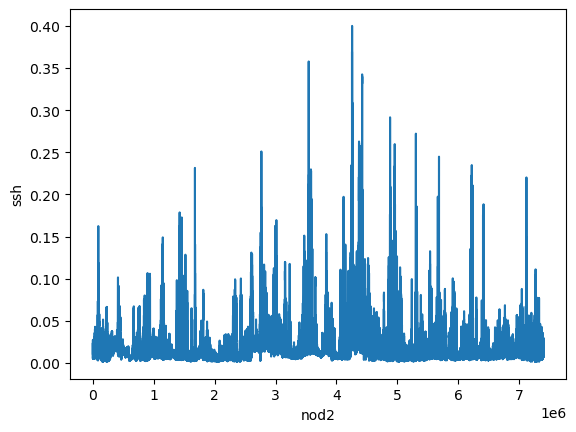

In [7]:
fesom_ssh_slice_std = fesom_ssh_slice.std(dim='time')
# print(fesom_ssh_slice_std)
fesom_ssh_slice_std.plot()

Trying to calculate std by reading only parts of data at a time.

In [8]:
%%time
sums = []
n = 0
for entry in fesom_ssh_slice:
    sums.append(entry.sum())
    n += entry.count()
mean = np.array(sums).sum() / n 
mean

CPU times: user 1.62 s, sys: 689 ms, total: 2.3 s
Wall time: 2.13 s


<xarray.DataArray 'ssh' ()>
array(-0.28957563)
Coordinates:
    time     datetime64[ns] 2020-01-20T00:56:00

In [9]:
%%time
from math import sqrt
sum_square_mean_diff = 0
for entry in fesom_ssh_slice:
    sum_square_mean_diff += ((entry - mean) ** 2).sum()
std = sqrt(sum_square_mean_diff / n)
std

CPU times: user 2.47 s, sys: 2.13 s, total: 4.61 s
Wall time: 4.28 s


0.6657240995455678

This gives the same result as using .mean() and .std() which reads all data at once.

In [10]:
print(fesom_ssh_slice.mean())
print(fesom_ssh_slice.std())

<xarray.DataArray 'ssh' ()>
array(-0.2895762, dtype=float32)
<xarray.DataArray 'ssh' ()>
array(0.6657224, dtype=float32)


# 4 - Regridding the std dataset using the AQUA regridder

In [11]:
fesom_ssh_slice_std_regrid = reader.regrid(fesom_ssh_slice_std)
fesom_ssh_slice_std_regrid

<xarray.DataArray 'ssh' (lat: 3600, lon: 7200)>
dask.array<reshape, shape=(3600, 7200), dtype=float64, chunksize=(3600, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.88 89.92 89.97
  * lon      (lon) float64 0.0 0.05 0.1 0.15 0.2 ... 359.8 359.9 359.9 359.9
Attributes:
    regridded:  1
    history:    2023-04-17 15:20:16 regridded by AQUA fixer;\n

# 5 - Visualizing the data

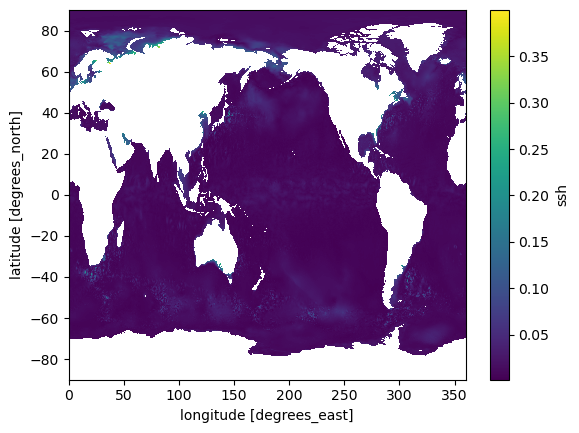

In [12]:
fesom_ssh_slice_std_regrid.plot()

adjusting the colorer range to make sense of the data

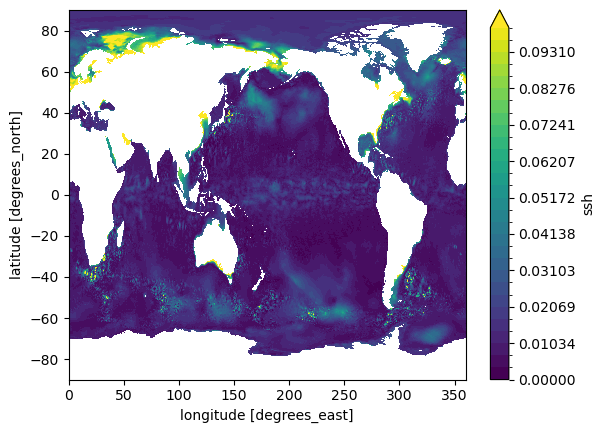

In [13]:
fesom_ssh_slice_std_regrid.plot(levels = np.linspace(0, 0.1, 30))

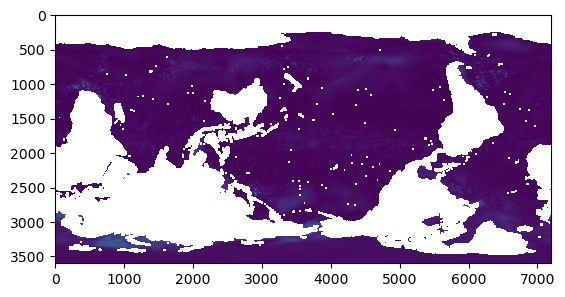

In [14]:
plt.imshow(fesom_ssh_slice_std_regrid.values)

In [15]:
# grid = xr.open_dataset('/work/bm1235/a270046/meshes/NG5_griddes_nodes_IFS.nc')
# model_lon = grid.grid_center_lon.values
# model_lat = grid.grid_center_lat.values
# #fesom sea surface height std
# plt.figure(figsize=(20,10))
# plt.scatter(model_lon, model_lat, s=1 , c=fesom_ssh_slice_std_regrid.ssh)
# plt.colorbar(orientation='horizontal', pad=0.04)

# 6 - Testing longer times hoping that they run without too much computation

In [16]:
fesom_ssh_slice = fesom_ssh[::10,:]
fesom_ssh_slice

<xarray.DataArray 'ssh' (time: 833, nod2: 7402886)>
dask.array<getitem, shape=(833, 7402886), dtype=float32, chunksize=(1, 7402886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T16:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

In [17]:
fesom_ssh_slice_std = fesom_ssh_slice.std(dim='time')
# print(fesom_ssh_slice_std)
# fesom_ssh_slice_std.plot()

In [18]:
fesom_ssh_slice_std_regrid = reader.regrid(fesom_ssh_slice_std)
# fesom_ssh_slice_std_regrid.plot()

QA link: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2017MS001099

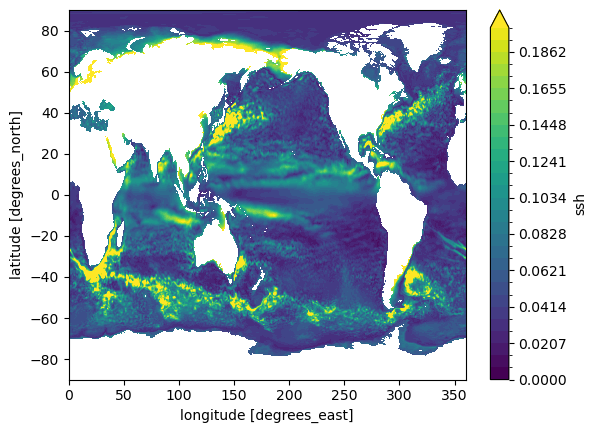

In [19]:
fesom_ssh_slice_std_regrid.plot(levels = np.linspace(0, 0.2, 30))